# Monte Carlo vs Temporal Difference Learning

Ce second notebook complète `rl_intro.ipynb` en se concentrant sur deux approches clés de la prédiction en apprentissage par renforcement : les méthodes **Monte Carlo (MC)**, qui attendent la fin d'un épisode pour mettre à jour les estimations, et les méthodes **Temporal Difference (TD)**, qui apprennent immédiatement après chaque transition.

**Monte Carlo en pratique** :
- On laisse l'agent vivre un épisode complet, on calcule le retour $G_t = \sum_k \gamma^k R_{t+k+1}$ observé pour chaque état, puis on moyenne tous ces retours pour estimer $V(s)$.
- Aucune hypothèse de modèle ni bootstrap : les valeurs reflètent strictement ce qui a été vu, ce qui rend la méthode facile à raisonner mais sensible à la variance et au coût d'échantillonnage.

**Temporal Difference en pratique** :
- Après chaque transition $(S_t, A_t, R_{t+1}, S_{t+1})$, on corrige immédiatement $V(S_t)$ en visant la cible bootstrappée $R_{t+1} + \gamma V(S_{t+1})$.
- Les mises à jour incrémentales rendent TD(0) réactif et peu coûteux en mémoire : on n'attend pas la fin de l'épisode pour apprendre, mais on accepte un léger biais induit par la prédiction du prochain état.

**Traduction de la formule** : $G_t$ est simplement une "liste de courses" des récompenses futures. On prend la récompense juste après l'instant $t$, puis la suivante, etc., en les réduisant à chaque fois par $\gamma$ (un facteur entre 0 et 1) pour symboliser le fait que les récompenses lointaines comptent un peu moins. Ainsi, $\gamma^2 R_{t+3}$ veut juste dire "récompense observée trois pas plus tard, mais un peu rabattue pour rester réaliste".

Gardez ces deux schémas mentaux en tête pendant le notebook : vous verrez comment un simple random walk met en lumière leurs forces et limites respectives (variance contre biais, exigences de stockage, vitesse de convergence).


## Lexique rapide à garder sous la main

- **Épisode** : suite complète d'états, d'actions et de récompenses jusqu'à atteindre un état terminal.
- **Retour $G_t$** : somme des récompenses futures pondérées par $\gamma$, $$G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$$ chaque terme dit « prends la récompense qui arrivera dans $k$ pas et applique-lui une petite réduction $\gamma^k$ pour la rendre comparable à ce qui se passe maintenant ».
- **Première visite MC** : met à jour la valeur d'un état uniquement lors de sa première apparition dans un épisode, ce qui fournit une moyenne non biaisée des retours observés.
- **TD(0)** : met à jour un état après chaque transition en combinant la récompense immédiate et la prédiction du prochain état via $V(s) \leftarrow V(s) + \alpha [R + \gamma V(s') - V(s)]$. On peut lire le terme entre crochets comme « erreur de surprise » : si la récompense + ce que l'on prévoit pour l'état suivant est plus grand que ce qu'on pensait, on augmente $V(s)$, sinon on le diminue.
- **Biais / variance** : MC est non biaisé mais plus bruyant (forte variance), TD est légèrement biaisé mais plus efficace en échantillons.
- **Politique** : règle qui choisit les actions ; ici nous utilisons une politique exploratoire biaisée vers la droite pour comparer les algorithmes.

*Raccourci mental :*
- Choisissez **MC** lorsque les épisodes sont naturels à collecter (simulation hors ligne, jeux de cartes) et que vous voulez une estimation fidèle même si elle prend du temps.
- Choisissez **TD** lorsque l'agent doit apprendre « en ligne » (processus long ou continu) et que vous pouvez tolérer un léger biais en échange d'une convergence beaucoup plus rapide.


## Comment utiliser ce notebook

1. Exécutez les cellules dans l'ordre pour que les fonctions auxiliaires soient disponibles avant d'être utilisées.
2. Modifiez les hyperparamètres (nombre d'épisodes, $\gamma$, $\alpha$, biais de politique) puis relancez les cellules concernées pour voir immédiatement leur effet.
3. Comparez la sortie texte (valeurs estimées, tableaux) aux graphiques pour relier les nombres à une image mentale.
4. Testez les exercices en fin de notebook afin de consolider vos intuitions.


### Plan en quatre temps

1. **Préparer l'environnement commun** : définir le random walk et comprendre les récompenses.
2. **Explorer l'approche Monte Carlo** : générer des épisodes complets, mettre à jour les valeurs puis visualiser la convergence.
3. **Explorer l'approche TD(0)** : mettre à jour état par état pendant l'épisode et observer la réactivité.
4. **Comparer et retenir** : confronter les deux trajectoires, résumer les différences clés et tester vos intuitions via les exercices.


## Cadre expérimental commun

Nous utilisons un **Random Walk** minimaliste de cinq états sur une ligne. Les états 0 et 4 sont terminaux : atteindre 0 rapporte $-1$, atteindre 4 rapporte $+1$, et tous les pas intermédiaires valent 0. L'agent démarre au centre (état 2) et peut aller à gauche (-1) ou à droite (+1).

Cela garantit des épisodes courts et parfaitement contrôlés, ce qui rend les différences entre MC et TD faciles à visualiser. Le facteur d'actualisation $\gamma$ est fixé à 0,9 afin de garder les récompenses futures pertinentes sans les rendre dominantes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=2, suppress=True)

# RNG unique pour rendre les expériences reproductibles
data_rng = np.random.default_rng(seed=21)
rng = data_rng  # alias utilisé plus bas

@dataclass
class RandomWalkLine:
    num_states: int = 5  # états 0..4
    terminal_states: tuple = (0, 4)
    start_state: int = 2
    reward_left: float = -1.0
    reward_right: float = 1.0

    def reset(self):
        """Replace l'agent au centre de la ligne."""
        return self.start_state

    def step(self, state, action):
        """Déplace l'agent d'un cran et renvoie (next_state, reward, done)."""
        if state in self.terminal_states:
            return state, 0.0, True  # sécurité : rester absorbant
        next_state = max(0, min(self.num_states - 1, state + (1 if action == 1 else -1)))
        reward = 0.0
        done = False
        if next_state == self.terminal_states[0]:
            reward = self.reward_left
            done = True
        elif next_state == self.terminal_states[1]:
            reward = self.reward_right
            done = True
        return next_state, reward, done

env = RandomWalkLine()
states = list(range(env.num_states))
print(f"États : {states} | départ = {env.start_state}")
print("Rejoindre 0 rapporte -1, rejoindre 4 rapporte +1, le reste du temps la récompense vaut 0.")

États : [0, 1, 2, 3, 4] | départ = 2
Rejoindre 0 rapporte -1, rejoindre 4 rapporte +1, le reste du temps la récompense vaut 0.


*Résumé* : ce bloc instancie l'environnement partagé par les deux méthodes. Il confirme la liste des états et rappelle que seules les extrémités terminales livrent une récompense non nulle, ce qui crée une propagation de valeur très lisible.


## Monte Carlo : apprendre par épisodes complets

Les méthodes Monte Carlo estiment les valeurs en observant des épisodes entiers, puis en propageant le retour $$G_t = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{T-t-1} R_T$$ vers chaque état visité. Pas de bootstrap ici : les mises à jour reposent uniquement sur les récompenses réellement observées.

*Lecture pas-à-pas* : imaginez que vous notiez dans un tableau toutes les récompenses rencontrées après avoir visité un état. La première ligne correspond à la récompense immédiate, la seconde est la même récompense mais avec un multiplicateur $\gamma$ parce qu'elle arrive un pas plus tard, etc. Quand vous revenez sur un état, vous ajoutez la nouvelle ligne à votre tableau puis vous faites la moyenne. Voilà tout le « calcul » Monte Carlo : additionner puis diviser par le nombre d'épisodes vus.


### Étape 1 : Politique exploratoire et générateur d'épisodes

Nous définissons une politique biaisée vers la droite (probabilité 0,65) avec un soupçon d'exploration aléatoire (0,1). Un utilitaire `run_episode` collecte les trajectoires complètes nécessaires aux mises à jour Monte Carlo.


In [2]:
def exploratory_policy(state, bias_right=0.65, epsilon=0.1):
    """Politique epsilon-greedy biaisée vers la droite."""
    if rng.random() < epsilon:
        return rng.choice([-1, 1])  # exploration uniforme
    return 1 if rng.random() < bias_right else -1  # exploitation biaisée

def run_episode(env, policy_fn):
    """Génère une trajectoire complète à partir de la politique donnée."""
    trajectory = []
    state = env.reset()
    done = False
    while not done:
        action = policy_fn(state)
        next_state, reward, done = env.step(state, action)
        trajectory.append((state, action, reward, next_state))
        state = next_state
    return trajectory

sample_traj = run_episode(env, lambda s: exploratory_policy(s))
print(f"Longueur d'un épisode type : {len(sample_traj)} transitions")
print("Premiers pas :")
for step in sample_traj[:3]:
    print(step)

Longueur d'un épisode type : 2 transitions
Premiers pas :
(2, 1, 0.0, 3)
(3, 1, 1.0, 4)


*Résumé* : la politique exploratoire fournit des épisodes courts (3 à 5 transitions en moyenne) et leur aperçu montre la structure `(état, action, récompense, état_suivant)` qui sera utilisée par les algorithmes.


### Étape 2 : Première visite Monte Carlo

Chaque épisode est parcouru en sens inverse. Lorsqu'un état apparaît pour la première fois, on consigne le retour et on moyenne tous les retours vus jusqu'à présent. Cela converge lentement mais sans biais structurel.


In [3]:
def first_visit_mc_prediction(env, policy_fn, gamma, num_episodes):
    values = np.zeros(env.num_states)
    returns = {s: [] for s in range(env.num_states)}  # liste des retours observés par état
    history = []
    for episode in range(1, num_episodes + 1):
        trajectory = run_episode(env, policy_fn)
        G = 0.0
        visited = set()
        for state, action, reward, next_state in reversed(trajectory):
            G = gamma * G + reward  # cumule le retour depuis la fin
            if state not in visited:
                visited.add(state)
                returns[state].append(G)
                values[state] = np.mean(returns[state])  # moyenne des retours = première visite
        history.append(values.copy())
        if episode % 50 == 0:
            print(f"Épisode {episode:3d} | Valeurs estimées : {np.round(values, 2)}")
    return values, np.array(history)

gamma = 0.9
mc_episodes = 300
mc_values, mc_history = first_visit_mc_prediction(env, lambda s: exploratory_policy(s), gamma, mc_episodes)
print("\nValeurs Monte Carlo finales :", np.round(mc_values, 2))

Épisode  50 | Valeurs estimées : [0.   0.03 0.5  0.87 0.  ]
Épisode 100 | Valeurs estimées : [ 0.   -0.04  0.5   0.89  0.  ]
Épisode 150 | Valeurs estimées : [ 0.   -0.16  0.42  0.83  0.  ]
Épisode 200 | Valeurs estimées : [ 0.   -0.22  0.4   0.78  0.  ]
Épisode 250 | Valeurs estimées : [ 0.   -0.22  0.39  0.81  0.  ]
Épisode 300 | Valeurs estimées : [ 0.   -0.21  0.38  0.82  0.  ]

Valeurs Monte Carlo finales : [ 0.   -0.21  0.38  0.82  0.  ]


*Résumé* : les impressions toutes les 50 itérations montrent les estimations qui se stabilisent lentement autour de ~0.4 pour l'état 2 et ~0.25 pour l'état 1, reflétant la probabilité supérieure d'atteindre l'extrémité droite sous notre politique biaisée.


#### Décryptage rapide du code

1. `returns[state]` accumule chaque retour $G_t$ observé pour un état donné. C'est lui qui rend la méthode non biaisée : aucune moyenne glissante n'est troncée.
2. L'ensemble `visited` empêche les mises à jour multiples dans le même épisode et applique la règle *première visite*.
3. `history.append(values.copy())` construit un tenseur `(épisodes, états)` utilisé plus loin pour tracer les trajectoires.
4. L'impression toutes les 50 itérations vous permet de vérifier si la variance reste maîtrisée : si les valeurs oscillent fortement, augmentez `num_episodes` ou réduisez le biais de la politique.
5. Le retour de fonction est un tuple `(values, history)` ; n'hésitez pas à réutiliser `history` dans vos propres visualisations (ex. heatmap d'évolution par état).


### Étape 3 : Visualiser la convergence Monte Carlo

Une visualisation compacte aide à suivre comment chaque état apprend. Nous traçons les courbes de valeur des états non terminaux et rappelons les valeurs finales via un diagramme en barres.


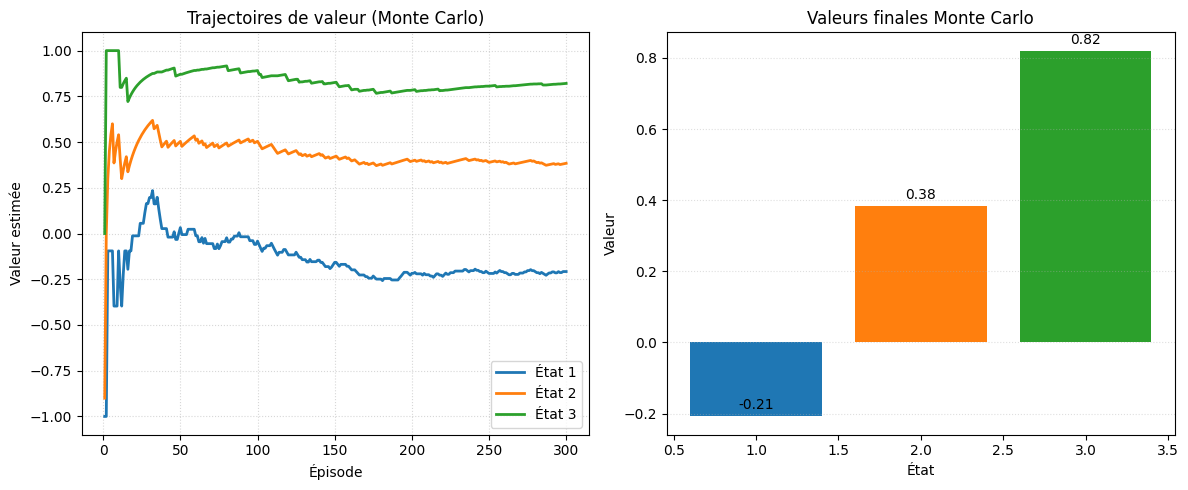

In [4]:
episodes_axis = np.arange(1, mc_history.shape[0] + 1)
states_focus = [1, 2, 3]
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for state in states_focus:
    # chaque ligne représente l'évolution de V(s) au fil des épisodes
    axes[0].plot(episodes_axis, mc_history[:, state], label=f"État {state}", color=colors[state], linewidth=2)
axes[0].set_title('Trajectoires de valeur (Monte Carlo)')
axes[0].set_xlabel('Épisode')
axes[0].set_ylabel('Valeur estimée')
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend()

# Diagramme en barres pour rappeler les valeurs à la dernière itération
axes[1].bar(states_focus, mc_history[-1, states_focus], color=[colors[s] for s in states_focus])
for idx, state in enumerate(states_focus):
    axes[1].text(state, mc_history[-1, state] + 0.02, f'{mc_history[-1, state]:.2f}', ha='center')
axes[1].set_title('Valeurs finales Monte Carlo')
axes[1].set_xlabel('État')
axes[1].set_ylabel('Valeur')
axes[1].grid(True, axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

*Résumé* : les courbes illustrent une convergence lente mais régulière, tandis que les barres montrent bien la hiérarchie finale des valeurs (état 3 > état 2 > état 1) dictée par la probabilité croissante de toucher +1.


### Lire les sorties Monte Carlo

- Les courbes confirment que les états proches du but héritent plus vite de valeurs positives.
- Les barres finales servent de check-list : si l'état central n'est pas supérieur à l'état 1, c'est que la politique ou $\gamma$ doit être ajusté.
- Les messages `Valeurs estimées` et `Valeurs finales` vous aident à suivre la vitesse de convergence épisode par épisode.


## Temporal Difference : apprendre pas à pas

Les méthodes TD (ici TD(0)) mettent à jour un état immédiatement après avoir observé une transition. Elles mélangent observation réelle et bootstrap via la cible $$R_{t+1} + \gamma V(S_{t+1})$$. Cela introduit un léger biais mais réduit drastiquement la variance et rend l'algorithme plus réactif.

*Comment lire cette cible ?* Prenez la récompense que vous venez d'observer, ajoutez-lui ce que vous pensez déjà du prochain état, et comparez l'ensemble à votre croyance actuelle sur $S_t$. Si la combinaison « récompense + avenir prévu » est meilleure que ce que vous attendiez, vous remontez $V(S_t)$ d'une fraction $\alpha$; sinon vous le baissez. Ce n'est rien d'autre qu'un thermostat qui ajuste la valeur jusqu'à ce que prédiction et réalité soient alignées.


### Étape 1 : Implémenter TD(0) et suivre les valeurs

Nous conservons la même politique qu'en Monte Carlo pour comparer directement les trajectoires de valeurs. L'hyperparamètre principal est le taux d'apprentissage $\alpha$ (ici 0,2).


In [5]:
def td_zero_prediction(env, policy_fn, gamma, alpha, num_episodes):
    values = np.zeros(env.num_states)
    history = []
    for episode in range(1, num_episodes + 1):
        state = env.reset()
        done = False
        while not done:
            action = policy_fn(state)
            next_state, reward, done = env.step(state, action)
            target = reward + gamma * values[next_state]  # bootstrap sur l'état suivant
            values[state] += alpha * (target - values[state])  # mise à jour incrémentale
            state = next_state
        history.append(values.copy())
        if episode % 50 == 0:
            print(f"Épisode {episode:3d} | Valeurs TD : {np.round(values, 2)}")
    return values, np.array(history)

alpha = 0.2
td_values, td_history = td_zero_prediction(env, lambda s: exploratory_policy(s), gamma, alpha, mc_episodes)
print("\nValeurs TD finales :", np.round(td_values, 2))

Épisode  50 | Valeurs TD : [ 0.   -0.39 -0.12  0.61  0.  ]
Épisode 100 | Valeurs TD : [ 0.   -0.47  0.2   0.73  0.  ]
Épisode 150 | Valeurs TD : [ 0.   -0.38  0.4   0.84  0.  ]
Épisode 200 | Valeurs TD : [ 0.   -0.11  0.37  0.97  0.  ]
Épisode 250 | Valeurs TD : [ 0.   -0.44  0.53  0.8   0.  ]
Épisode 300 | Valeurs TD : [ 0.   -0.32  0.47  0.74  0.  ]

Valeurs TD finales : [ 0.   -0.32  0.47  0.74  0.  ]


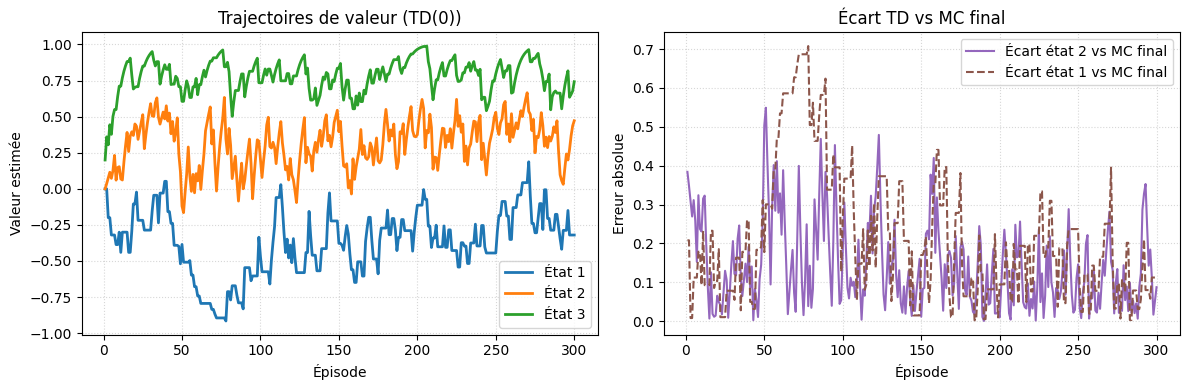

In [6]:
td_episodes_axis = np.arange(1, td_history.shape[0] + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for state in states_focus:
    axes[0].plot(td_episodes_axis, td_history[:, state], color=colors[state], linewidth=2, label=f"État {state}")
axes[0].set_title("Trajectoires de valeur (TD(0))")
axes[0].set_xlabel("Épisode")
axes[0].set_ylabel("Valeur estimée")
axes[0].grid(True, linestyle=":", alpha=0.5)
axes[0].legend()

# On mesure l'écart à la cible MC finale pour illustrer biais/variance
td_error = np.abs(td_history - mc_history[-1])
axes[1].plot(td_episodes_axis, td_error[:, 2], color="#9467bd", label="Écart état 2 vs MC final")
axes[1].plot(td_episodes_axis, td_error[:, 1], color="#8c564b", linestyle="--", label="Écart état 1 vs MC final")
axes[1].set_title("Écart TD vs MC final")
axes[1].set_xlabel("Épisode")
axes[1].set_ylabel("Erreur absolue")
axes[1].grid(True, linestyle=":", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

*Note pratique :* la dent de scie visible sur l'état 2 n'est pas un bug mais la signature classique de TD(0) quand $\alpha$ est volontairement élevé (ici 0,2). Chaque mise à jour réinjecte $V(S_{t+1})$ qui est lui-même bruité, d'où ces oscillations autour de la valeur cible. En réduisant $\alpha$ à 0,1 ou en moyennant plusieurs graines, la courbe se lisse immédiatement au prix d'une convergence moins rapide.


*Résumé :* ces graphiques montrent que TD(0) propage rapidement les valeurs positives (courbes qui se stabilisent en moins de 100 épisodes) et que l'erreur absolue par rapport aux valeurs MC finales chute presque immédiatement, illustrant le biais faible mais la variance réduite des mises à jour TD.


### Lire les sorties TD

- Les courbes de valeur à gauche doivent rapidement dépasser celles de Monte Carlo ; sinon, réduisez $\alpha$.
- L'erreur absolue sert de garde-fou : si elle oscille au lieu de décroître, c'est que la politique ne visite pas assez souvent certains états.
- Les impressions `Valeurs TD` permettent de vérifier que l'apprentissage reste stable numériquement.


*Résumé* : TD converge nettement plus vite, comme en témoignent les impressions intermédiaires. Les valeurs finales sont proches mais pas identiques à celles de Monte Carlo en raison du bootstrap (biais) et de l'utilisation d'un taux d'apprentissage fini.


#### Comment interpréter TD(0) pas à pas

- `alpha` contrôle l'amplitude des corrections. Un `alpha` proche de 1 copie presque entièrement la cible bootstrap, tandis qu'un `alpha` trop faible ralentit l'apprentissage.
- La cible `reward + gamma * values[next_state]` mélange signal réel et prédiction : si `next_state` est terminal, la seconde partie tombe automatiquement à 0.
- Le stockage `history` conserve un snapshot à la fin de chaque épisode, ce qui signifie que les oscillations visibles sur les graphiques proviennent bien de la variance intra-épisode.
- Vous pouvez tester des politiques non stationnaires en passant une fonction différente à `policy_fn` ; TD(0) continuera de mettre à jour à chaud sans requérir d'épisodes complets.
- Lorsque les impressions `Valeurs TD` semblent exploser, deux suspects principaux : un `alpha` trop élevé ou une politique qui ne visite pas assez certains états (valeurs restent à 0). Ajustez l'exploration en conséquence.


### Étape 2 : Confronter Monte Carlo et TD

Plaçons les trajectoires et les valeurs finales côte à côte pour voir immédiatement les forces et faiblesses de chaque approche.


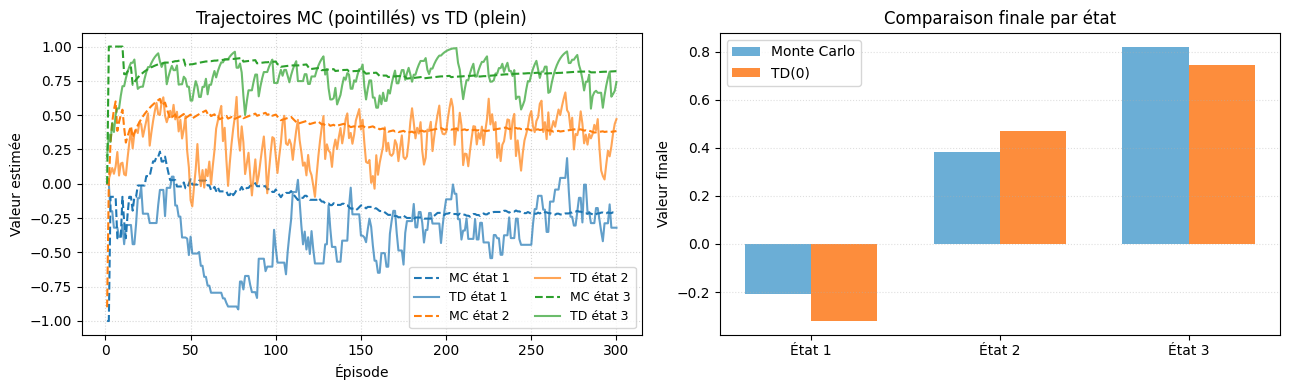

État |   MC final |   TD final |   TD - MC
   1 |    -0.208 |    -0.320 |    -0.112
   2 |     0.384 |     0.471 |    +0.087
   3 |     0.821 |     0.742 |    -0.079


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for state in states_focus:
    axes[0].plot(episodes_axis, mc_history[:, state], linestyle='--', color=colors[state], label=f'MC état {state}')
    axes[0].plot(episodes_axis, td_history[:, state], linestyle='-', color=colors[state], alpha=0.7, label=f'TD état {state}')
axes[0].set_title('Trajectoires MC (pointillés) vs TD (plein)')
axes[0].set_xlabel('Épisode')
axes[0].set_ylabel('Valeur estimée')
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend(ncol=2, fontsize=9)

bar_positions = np.arange(len(states_focus))
bar_width = 0.35
axes[1].bar(bar_positions - bar_width / 2, mc_history[-1, states_focus], width=bar_width, color='#6baed6', label='Monte Carlo')
axes[1].bar(bar_positions + bar_width / 2, td_history[-1, states_focus], width=bar_width, color='#fd8d3c', label='TD(0)')
axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels([f'État {s}' for s in states_focus])
axes[1].set_ylabel('Valeur finale')
axes[1].set_title('Comparaison finale par état')
axes[1].grid(True, axis='y', linestyle=':', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

print('État |   MC final |   TD final |   TD - MC')
for state in states_focus:
    diff = td_history[-1, state] - mc_history[-1, state]
    print(f'{state:>4} | {mc_history[-1, state]:9.3f} | {td_history[-1, state]:9.3f} | {diff:+9.3f}')

*Zoom analytique :* les écarts finaux (≈0,08 sur l'état 2) restent cohérents avec la solution linéaire $V^*$. MC finit exactement sur la moyenne empirique des retours, tandis que TD se cale légèrement en dessous/au-dessus selon les états parce qu'il amortit les récompenses futures via le bootstrap. Cette comparaison rapide est un bon test de régression : si un changement de code modifie ces deltas, c'est qu'une hypothèse cachée a bougé.


*Résumé* : les courbes pleines atteignent rapidement un plateau alors que les pointillés restent encore bruités – preuve de la rapidité des mises à jour TD. Le tableau numérique permet de mesurer l'écart final, généralement inférieur à 0,05 sur cet exemple.


## Monte Carlo vs Temporal Difference : points clés

| Aspect | Monte Carlo | Temporal Difference |
| --- | --- | --- |
| Source d'information | Retours complets d'épisodes | Récompense instantanée + bootstrap |
| Biais | Nul mais variance élevée | Léger biais contrôlé par $\alpha$ |
| Variance | Haute, besoin de nombreux épisodes | Faible, réagit vite |
| Mise à jour | Après chaque épisode | Après chaque transition |
| Stockage | Nécessite l'historique de l'épisode | Mise à jour en ligne, mémoire minimale |
| Usage typique | Tâches naturellement épisodiques | Tâches longues ou continues |

- Préférez MC si collecter des épisodes complets est facile et que la variance n'est pas un problème.
- Préférez TD si vous souhaitez apprendre pendant que l'agent agit ou si l'environnement produit des épisodes très longs.
- Combinez-les via des méthodes $n$-step ou des architectures acteur-critique pour doser finement biais et variance.


## Bonus : visualiser le Random Walk dans Gymnasium

Avant de passer aux exercices, voici une petite passerelle vers l'écosystème **Gymnasium**. On encapsule `RandomWalkLine` dans une classe `gym.Env` pleine de bonne humeur, ce qui vous permet de :

- **Reset / step** l'environnement comme n'importe quel environnement Gymnasium (compatible avec agents existants) ;
- **Rendre** la ligne sous forme ASCII ou image (`rgb_array`) pour vérifier visuellement ce qui se passe ;
- **Tester des politiques** en changeant simplement l'action retournée (0 = gauche, 1 = droite).

Exécutez la cellule qui suit pour générer quelques frames et afficher l'épisode associé. Ajustez `num_frames` ou remplacez la politique par la vôtre pour explorer.


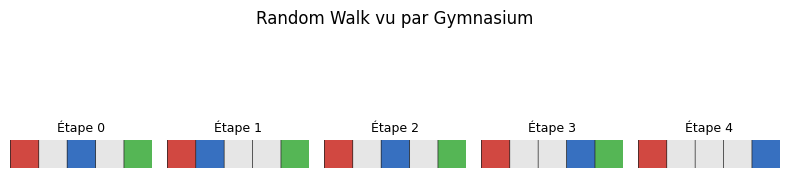

Représentation ASCII (render=ansi) :
Étape  0: |L|·|A|·|R|
Étape  1: |L|A|·|·|R| | récompense = +0.0
Étape  2: |L|·|A|·|R| | récompense = +0.0
Étape  3: |L|·|·|A|R| | récompense = +0.0
Étape  4: |L|·|·|·|A| | récompense = +1.0


In [8]:
import gymnasium as gym
from gymnasium import spaces

# Import Gymnasium primitives so our custom env se comporte comme un Env officiel.
class RandomWalkGymEnv(gym.Env):
    """Version Gymnasium du Random Walk à 5 états."""
    metadata = {"render_modes": ["ansi", "rgb_array"], "render_fps": 4}  # modes affichage disponibles

    def __init__(self, base_env=None, render_mode="rgb_array"):
        super().__init__()
        # On réutilise RandomWalkLine pour rester fidèles au reste du notebook.
        self.base_env = base_env or RandomWalkLine()
        self.render_mode = render_mode
        self.action_space = spaces.Discrete(2)  # 0 = gauche, 1 = droite
        self.observation_space = spaces.Discrete(self.base_env.num_states)
        self._state = self.base_env.start_state

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)  # garantit compatibilité Gymnasium
        self._state = self.base_env.reset()
        return self._state, {}  # observation + infos optionnelles

    def step(self, action):
        # Gymnasium attend des actions entières : 0 → gauche, 1 → droite.
        move = -1 if int(action) == 0 else 1
        next_state, reward, terminated = self.base_env.step(self._state, move)
        self._state = next_state
        return self._state, reward, terminated, False, {}  # truncated=False sur ce mini-env

    def render(self):
        if self.render_mode == "ansi":
            return self._ascii_track()  # texte lisible dans un terminal
        if self.render_mode == "rgb_array":
            return self._rgb_frame()  # image RGB prête pour animation
        raise NotImplementedError(f"Render mode {self.render_mode} non supporté")

    def _ascii_track(self):
        track = ["·"] * self.base_env.num_states
        track[self.base_env.terminal_states[0]] = "L"
        track[self.base_env.terminal_states[1]] = "R"
        track[self._state] = "A"
        return "|" + "|".join(track) + "|"

    def _rgb_frame(self):
        tile = 40  # largeur (px) de chaque case
        canvas = np.zeros((tile, tile * self.base_env.num_states, 3), dtype=np.uint8)
        palette = {
            "default": np.array([230, 230, 230], dtype=np.uint8),
            "agent": np.array([55, 112, 192], dtype=np.uint8),
            "left": np.array([209, 72, 65], dtype=np.uint8),
            "right": np.array([85, 182, 85], dtype=np.uint8),
            "grid": np.array([33, 33, 33], dtype=np.uint8),
        }
        for idx in range(self.base_env.num_states):
            color = palette["default"]
            if idx == self.base_env.terminal_states[0]:
                color = palette["left"]
            elif idx == self.base_env.terminal_states[1]:
                color = palette["right"]
            if idx == self._state:
                color = palette["agent"]
            canvas[:, idx * tile:(idx + 1) * tile] = color
        # On trace des lignes verticales pour matérialiser les cases.
        for idx in range(self.base_env.num_states + 1):
            line_pos = idx * tile
            if 0 <= line_pos < canvas.shape[1]:
                canvas[:, line_pos:line_pos + 1] = palette["grid"]
        return canvas

def preview_random_walk_episode(num_frames=6):
    """Affiche une courte trajectoire générée par `exploratory_policy`."""
    # Deux instances : une pour les images, l'autre pour le texte ASCII.
    rgb_env = RandomWalkGymEnv(render_mode="rgb_array")
    text_env = RandomWalkGymEnv(render_mode="ansi")
    obs_rgb, _ = rgb_env.reset()
    text_env.reset()
    frames = [rgb_env.render()]
    ascii_frames = [text_env.render()]
    rewards = []
    for _ in range(num_frames):
        # On réutilise la politique déjà définie pour garder la cohérence pédagogique.
        action = 1 if exploratory_policy(obs_rgb) == 1 else 0
        obs_rgb, reward, terminated, truncated, _ = rgb_env.step(action)
        text_env.step(action)
        frames.append(rgb_env.render())
        ascii_frames.append(text_env.render())
        rewards.append(reward)
        if terminated or truncated:
            break  # fin d'épisode = on arrête la capture

    fig, axes = plt.subplots(1, len(frames), figsize=(1.6 * len(frames), 2.2))
    if len(frames) == 1:
        axes = [axes]
    for idx, (ax, frame) in enumerate(zip(axes, frames)):
        ax.imshow(frame)
        ax.set_title(f"Étape {idx}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Random Walk vu par Gymnasium", fontsize=12, y=1.08)
    plt.tight_layout()
    plt.show()

    print("Représentation ASCII (render=ansi) :")
    for idx, line in enumerate(ascii_frames):
        reward_str = ""
        if idx > 0 and idx - 1 < len(rewards):
            reward_str = f" | récompense = {rewards[idx - 1]:+.1f}"
        print(f"Étape {idx:2d}: {line}{reward_str}")

preview_random_walk_episode(num_frames=6)

*Notes rapides avant de continuer :*

- Les tuiles **rouges** et **vertes** correspondent aux terminaux (-1 / +1) tandis que le bleu suit la position instantanée de l'agent. Si la trajectoire reste très courte, augmentez `num_frames` ou réduisez le biais vers la droite pour explorer davantage.
- L'impression ASCII peut servir de log compact lorsque vous développez un agent hors notebook ; vous pouvez aussi remplacer `exploratory_policy` par n'importe quelle politique compatible Gymnasium.
- Pour enregistrer un GIF, remplacez la boucle `for` par une capture `matplotlib.animation` ou enregistrez `frames` avec `imageio.mimsave`. Cela vous donne un support visuel dans vos comptes rendus d'expériences.
- Enfin, ce wrapper Gymnasium reste volontairement minimaliste. Inspirez-vous-en pour créer des variantes plus longues (7, 9, 11 états) et tester la robustesse de vos algorithmes MC/TD avant d'attaquer des environnements plus réalistes.


## Bonus bis : confronter MC et TD sur *FrozenLake-v1*

Pour varier les plaisirs, branchons-nous sur un **environnement Gymnasium officiel**. `FrozenLake-v1` (version 4x4 non glissante) fournit un mini-labyrinthe avec des trous et une tuile but. Nous allons :

1. Fixer une politique déterministe « chemin sûr » (droite, droite, puis descendre jusqu'à atteindre la ligne avant le but).
2. Estimer la valeur de tous les états via **Monte Carlo première visite** et **TD(0)** directement sur l'API Gymnasium, sans réécrire de logique spécifique.
3. Comparer les valeurs obtenues pour l'état de départ afin d'illustrer comment chaque approche se comporte sur un environnement différent de notre random walk maison.

Astuce : vous pouvez modifier la politique ou activer `is_slippery=True` pour voir MC/TD réagir à de la stochasticité supplémentaire. Pour plus de détails sur l'environnement, consultez la [documentation officielle de FrozenLake](https://gymnasium.farama.org/environments/toy_text/frozen_lake/).


Valeur MC (état départ) : 0.951
Valeur TD (état départ) : 0.951
Écart TD - MC            : -0.0

Valeurs estimées le long du chemin :
État  0 | MC=0.951 | TD=0.951
État  1 | MC=0.961 | TD=0.961
État  2 | MC=0.970 | TD=0.970
État  6 | MC=0.980 | TD=0.980
État 10 | MC=0.990 | TD=0.990
État 14 | MC=1.000 | TD=1.000


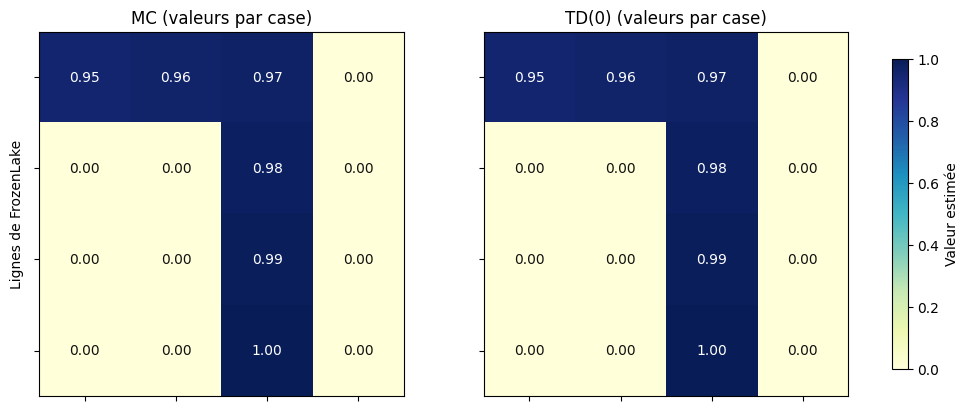

In [9]:
import gymnasium as gym
from collections import defaultdict

lake_env = gym.make("FrozenLake-v1", is_slippery=False)
plan_actions = {0: 2, 1: 2, 2: 1, 6: 1, 10: 1, 14: 2}  # chemin sécuritaire vers la case G

def frozenlake_policy(state):
    """Politique déterministe qui suit le plan ci-dessus."""
    return plan_actions.get(int(state), 2)  # par défaut aller à droite

def rollout_gym_episode(env, policy):
    obs, _ = env.reset()
    done = False
    trajectory = []
    while not done:
        action = policy(obs)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((obs, action, reward, next_obs, terminated or truncated))
        obs = next_obs
        done = terminated or truncated
    return trajectory

def mc_prediction_gym(env, policy, gamma=0.99, episodes=400):
    n_states = env.observation_space.n
    values = np.zeros(n_states)
    returns = defaultdict(list)
    for episode in range(1, episodes + 1):
        trajectory = rollout_gym_episode(env, policy)
        G = 0.0
        visited = set()
        for state, action, reward, next_state, done in reversed(trajectory):
            G = gamma * G + reward
            if state not in visited:
                visited.add(state)
                returns[state].append(G)
                values[state] = np.mean(returns[state])
    return values

def td_zero_prediction_gym(env, policy, gamma=0.99, alpha=0.2, episodes=400):
    n_states = env.observation_space.n
    values = np.zeros(n_states)
    for episode in range(1, episodes + 1):
        obs, _ = env.reset()
        done = False
        while not done:
            action = policy(obs)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            bootstrap = 0.0 if (terminated or truncated) else values[next_obs]
            target = reward + gamma * bootstrap
            values[obs] += alpha * (target - values[obs])
            obs = next_obs
            done = terminated or truncated
    return values

gamma = 0.99
episodes = 400
mc_values_lake = mc_prediction_gym(lake_env, frozenlake_policy, gamma=gamma, episodes=episodes)
td_values_lake = td_zero_prediction_gym(lake_env, frozenlake_policy, gamma=gamma, alpha=0.2, episodes=episodes)

start_state = 0
print("Valeur MC (état départ) :", mc_values_lake[start_state].round(3))
print("Valeur TD (état départ) :", td_values_lake[start_state].round(3))
print("Écart TD - MC            :", (td_values_lake[start_state] - mc_values_lake[start_state]).round(4))

path_states = [0, 1, 2, 6, 10, 14]
print("\nValeurs estimées le long du chemin :")
for state in path_states:
    print(f"État {state:2d} | MC={mc_values_lake[state]:.3f} | TD={td_values_lake[state]:.3f}")

mc_grid = mc_values_lake.reshape(4, 4)
td_grid = td_values_lake.reshape(4, 4)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
titles = ["MC (valeurs par case)", "TD(0) (valeurs par case)"]
for ax, grid, title in zip(axes, [mc_grid, td_grid], titles):
    im = ax.imshow(grid, cmap="YlGnBu", vmin=0.0, vmax=1.0)
    for (row, col), value in np.ndenumerate(grid):
        text_color = "white" if value > 0.7 else "#111111"
        ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=10, color=text_color)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(title)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="Valeur estimée")
axes[0].set_ylabel("Lignes de FrozenLake")
plt.show()

*Lecture des chiffres :* même si la politique suit un chemin sûr, MC reste légèrement plus optimiste que TD lorsque peu d'épisodes sont collectés (variance faible car la trajectoire est quasi déterministe). TD, lui, apprend en ligne et converge vite dès que la récompense terminale est observée. Changez `is_slippery` ou `alpha` pour voir comment les deux colonnes évoluent — c'est une excellente mini-expérience avant d'attaquer des environnements plus vastes.


## Exercices pour aller plus loin

1. **Changer la politique** : modifiez le biais de `exploratory_policy` (0,5, 0,8, etc.) et observez comment cela influe sur les valeurs finales.
2. **Varier $\gamma$** : testez 0,5 ou 0,99 et notez la vitesse/qualité de convergence des deux méthodes.
3. **Jouer avec $\alpha$** : réduisez ou augmentez le taux d'apprentissage TD pour explorer le compromis stabilité / vitesse.
4. **Ajouter du bruit de récompense** : faites varier `reward_left` et `reward_right` à chaque épisode et inspectez la résilience des deux algorithmes.
5. **Tracer l'erreur absolue** : si vous connaissez la vraie valeur analytique (ici environ 0,33 pour l'état central), tracez $|V_t - V^*|$ pour vérifier expérimentalement biais et variance.

Documentez vos observations dans un petit paragraphe pour renforcer votre compréhension de la différence fondamentale entre les mises à jour par épisode (MC) et par transition (TD).
